In [10]:
!pip install sentence-transformers

In [11]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket match by 5 wickets",

    # Cooking
    "I prepared pasta using fresh ingredients",
    "The chef cooked a delicious meal",
    "Baking a cake requires precise measurements",

    # Cybersecurity
    "Strong passwords are essential for security",
    "The system was hacked due to vulnerabilities",
    "Encryption protects sensitive data",
    "Firewall prevents unauthorized access"
]

In [12]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


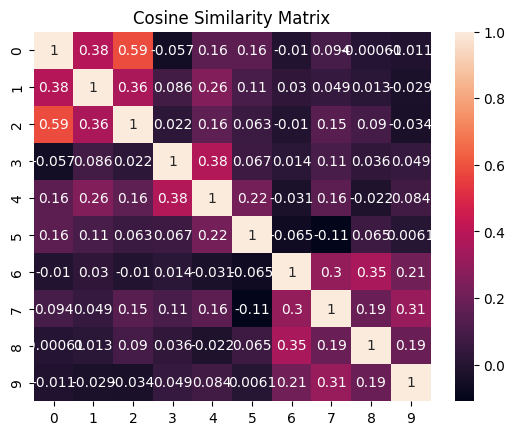

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure()
sns.heatmap(similarity_matrix, annot=True)
plt.title("Cosine Similarity Matrix")
plt.show()

In [14]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(sentences[idx], "->", similarities[idx])

The team won the cricket match by 5 wickets -> 0.7184911
The batsman scored a century in the match -> 0.56821966
